In [1]:
# Alternative: Ultra-minimalist confusion matrix (if you want even cleaner look)
def plot_minimal_confusion_matrix(y_true, y_pred, title, figsize=(10, 8)):
    """
    Ultra-clean confusion matrix with minimal styling - only essential info.
    """
    # Round and convert
    y_true_rounded = np.round(y_true * 2) / 2
    y_pred_rounded = np.round(y_pred * 2) / 2
    y_true_str = [f"{x:.1f}" for x in y_true_rounded]
    y_pred_str = [f"{x:.1f}" for x in y_pred_rounded]
    
    scores = np.arange(0, 10.5, 0.5)
    scores_str = [f"{x:.1f}" for x in scores]
    
    cm = confusion_matrix(y_true_str, y_pred_str, labels=scores_str)
    
    # Create minimal figure
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    
    # Use very light blue-gray colormap
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues', 
                   vmin=0, vmax=cm.max()*0.7, alpha=0.7)
    
    # Minimal ticks - show fewer labels
    tick_positions = np.arange(0, len(scores), 2)  # Every other score
    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)
    ax.set_xticklabels([scores[i] for i in tick_positions], fontsize=10)
    ax.set_yticklabels([scores[i] for i in tick_positions], fontsize=10)
    
    # Add numbers only where count > 0
    for i in range(len(scores)):
        for j in range(len(scores)):
            if cm[i, j] > 0:
                ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                       color='white' if cm[i, j] > cm.max()*0.4 else 'black',
                       fontsize=9, fontweight='bold')
    
    # Minimal labels
    ax.set_ylabel('Ground Truth', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    # Remove spines for ultra-clean look
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    plt.tight_layout()
    return fig

print("✨ Choose your preferred style:")
print("- plot_confusion_matrix() → Clean with light colors, counts only")
print("- plot_minimal_confusion_matrix() → Ultra-minimal, super clean")
print()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

# Load your CSV file
csv_path = "/home/user01/aiotlab/sondinh/Flamingo/audio-flamingo/audio_flamingo_2/train/test_result_corrected_full.csv"  # Change this to your CSV path
df = pd.read_csv(csv_path)

print(f"Dataset loaded: {len(df)} samples")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset loaded: 12325 samples

Columns: ['Audio File', 'Prompt', 'Ground Truth', 'Prediction', 'GT Total', 'GT Vocabulary', 'GT Grammar', 'GT Pronunciation', 'GT Fluency', 'GT Discourse', 'Pred Total', 'Pred Vocabulary', 'Pred Grammar', 'Pred Pronunciation', 'Pred Fluency', 'Pred Discourse']

First few rows:


,Audio File,Prompt,Ground Truth,Prediction,GT Total,GT Vocabulary,GT Grammar,GT Pronunciation,GT Fluency,GT Discourse,Pred Total,Pred Vocabulary,Pred Grammar,Pred Pronunciation,Pred Fluency,Pred Discourse
0,/home/user06/data/Speaking_VSTEP/SPEAKING/11. ...,"you are an expert english-speaking examiner, s...",total: 4.0/10\nvocabulary: 4.0/10\ngrammar: 4....,total: 5.5/10\nvocabulary: 4.0/10\ngrammar: 4....,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
1,/home/user06/data/Speaking_VSTEP/SPEAKING/42. ...,"you are an expert english-speaking examiner, s...",total: 4.5/10\nvocabulary: 5.0/10\ngrammar: 4....,total: 5.5/10\nvocabulary: 4.0/10\ngrammar: 5....,4.5,5.0,4.5,4.5,4.5,5.0,4.5,4.0,5.5,4.5,4.5,5.0
2,/home/user06/data/Speaking_VSTEP/SPEAKING/28. ...,"you are an expert english-speaking examiner, s...",total: 4.5/10\nvocabulary: 4.0/10\ngrammar: 5....,total: 4.5/10\nvocabulary: 4.0/10\ngrammar: 4....,4.5,4.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0
3,/home/user06/data/Speaking_VSTEP/DATA_Vocal/CD...,"you are an expert english-speaking examiner, s...",total: 6.5/10\nvocabulary: 7.0/10\ngrammar: 7....,total: 7.5/10\nvocabulary: 6.0/10\ngrammar: 7....,6.5,7.0,7.0,6.0,6.0,6.0,6.0,6.0,7.0,6.0,6.0,6.0
4,/home/user06/data/Speaking_VSTEP/SPEAKING/24. ...,"you are an expert english-speaking examiner, s...",total: 7.0/10\nvocabulary: 7.0/10\ngrammar: 7....,total: 7.5/10\nvocabulary: 7.0/10\ngrammar: 7....,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0


In [5]:
# Calculate absolute errors for each of the 5 categories
df['total_errorgr = abs(df['Pred Total'] - df['GT Total'])ammarvocabulary_error'] = abs(df['Pred Vocabulary'] - df['GT Vocabulary'])
df['_error'] = abs(df['Pred Grammar'] - df['GT Grammar'])
df['vocab_eprrnunoirtion] = abs(df['Pred Vocab']Pr-nun idtion['GT Vocab']Pr
nundiftion'discourflr'ncy] = abs(df['Pred DiscourFl-fncy['GT DiscourFl
[ncy'total_ediscrurse] = abs(df['Pred Total']Disc-urse['GT Total']Disc
urseRemove rows with NaN values for analysis
df_cle - update for 5 categoriesan = df.dropna(subset=['GT GrammarTotal', ''T Vocabula,y', 'GT Gr 'GT Vocab',Pr'nunGiTtion', 'GT FluencyDiscourse', 'GT To
  t,                       'Pr'PredeTotal',d'Pred Vocabulary',Grammar', 'Pred Vocab',Pr'nunPirtiond DiscourFl'encyd Total']Disc
urseint(f"Clean dataset: {len(df_clean)} samples (removed {len(df) - len(df_clean)} NaN rows)")
print("\nError Statistics:")
pri (MAE)nt(f"GrammarTot ldf_cl         ean['grammartotrl].mean():.4f}")
print(f"Vocabulary MAE: {df_cl    ean['vocab_error'ulary_error'].mean():.4f}")
print(f"Grammar MAE:        {df_clean['grammar].mean():.4f}")
print(f"DiscourPronunciateon MAE:  {df_Mlean['prAnEnciation_error'].mean():.4f}")
p:int(f"Flu{ncydf_cl       ean['discourflr'ncy].mean():.4f}")
print(f"Total MDiscEursedf_cl     ean['total_ediscrurse].mean():.4f}")

Clean dataset: 12325 samples (removed 0 NaN rows)

Error Statistics (MAE):
Total MAE:          0.0748
Vocabulary MAE:     0.2744
Grammar MAE:        0.2419
Pronunciation MAE:  0.2626
Fluency MAE:        0.2317
Discourse MAE:      0.2241


In [6]:
def calculate_error_distribution(errors):
    """Calculate percentage of samples in each error range."""
    total = len(errors)
    exact = (errors == 0).sum()
    half = ((errors > 0) & (errors <= 0.5)).sum()
    one = ((errors > 0.5) & (errors <= 1.0)).sum()
    above_one = (errors > 1.0).sum()
    
    return {
        'Exact (0)': f"{exact} ({exact/total*100:.1f}%)",
        'Small (0-0.5]': f"{half} ({half/total*100:.1f}%)",
        'Medium (0.5-1.0]': f"{one} ({one/total*100:.1f}%)",
        'Large (>1.0)': f"{above_one} ({above_one/total*100:.1f}%)"
    }

# Create error distribution table for all 5 categories
error_dist = pd.DataFrame({
    'Total': calculate_error_distribution(df_clean['total_error']),
    'Vocabulary': calculate_error_distribution(df_clean['vocabulary_error']),
    'Grammar': calculate_error_distribution(df_clean['grammar_error']),
    'Pronunciation': calculate_error_distribution(df_clean['pronunciation_error']),
    'Fluency': calculate_error_distribution(df_clean['fluency_error']),
    'Discourse': calculate_error_distribution(df_clean['discourse_error'])
})

print("="*100)
print("ERROR DISTRIBUTION BY CATEGORY (All 5 Categories)")
print("="*100)
print(error_dist)
print("="*100)

ERROR DISTRIBUTION BY CATEGORY (All 5 Categories)
                          Total    Vocabulary       Grammar Pronunciation  \
Exact (0)         10491 (85.1%)  7861 (63.8%)  8562 (69.5%)  8364 (67.9%)   
Small (0-0.5]      1829 (14.8%)  2204 (17.9%)  1676 (13.6%)  1649 (13.4%)   
Medium (0.5-1.0]       3 (0.0%)  2221 (18.0%)  1973 (16.0%)  2115 (17.2%)   
Large (>1.0)           2 (0.0%)     39 (0.3%)    114 (0.9%)    197 (1.6%)   

                       Fluency     Discourse  
Exact (0)         8607 (69.8%)  8936 (72.5%)  
Small (0-0.5]     1842 (14.9%)  1413 (11.5%)  
Medium (0.5-1.0]  1773 (14.4%)  1834 (14.9%)  
Large (>1.0)        103 (0.8%)    142 (1.2%)  


🎨 Available color styles:
1. 'soft' - Light Purple
2. 'ocean' - Light Blue
3. 'mint' - Light Green
4. 'sunset' - Light Orange
5. 'forest' - Light Teal
6. 'rose' - Light Red

📊 Total Score Confusion Matrix


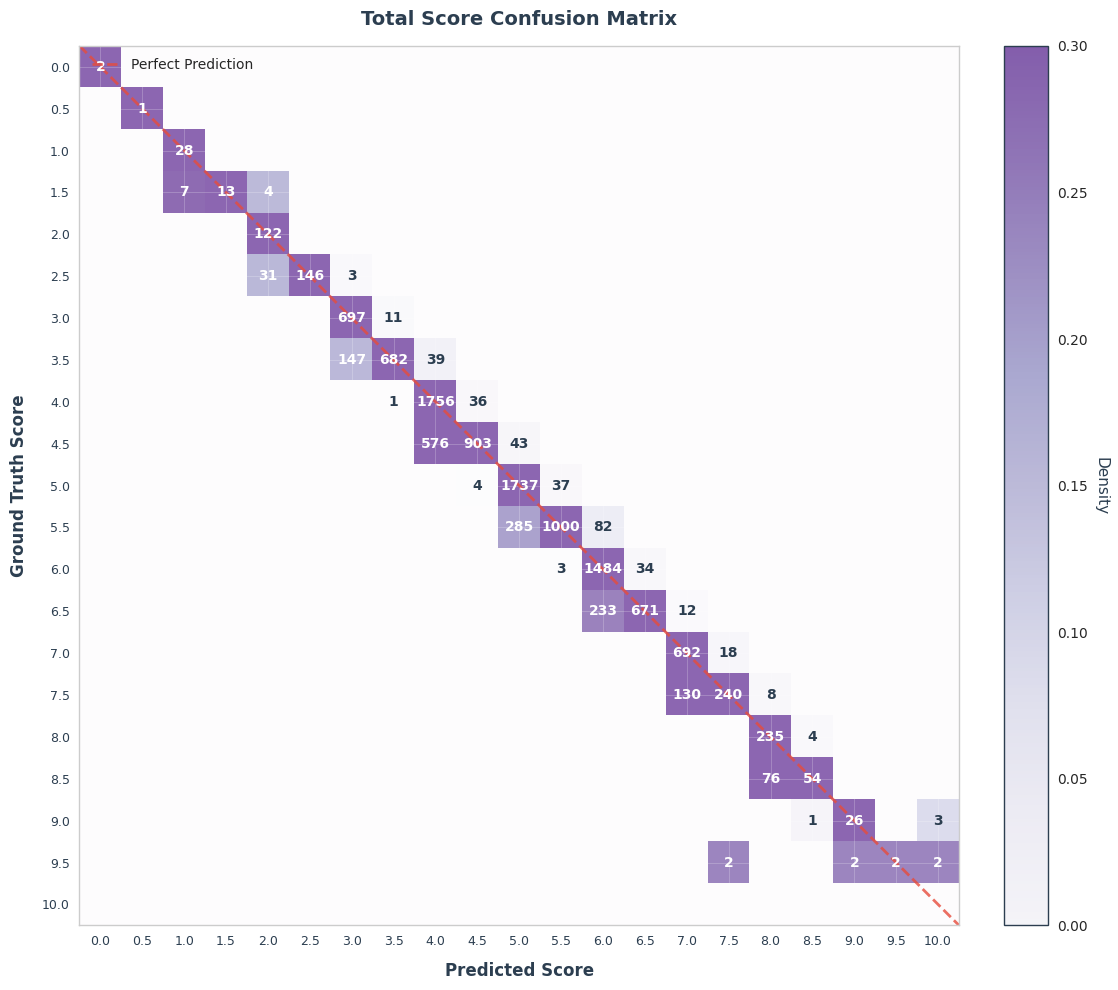

📊 Vocabulary Confusion Matrix


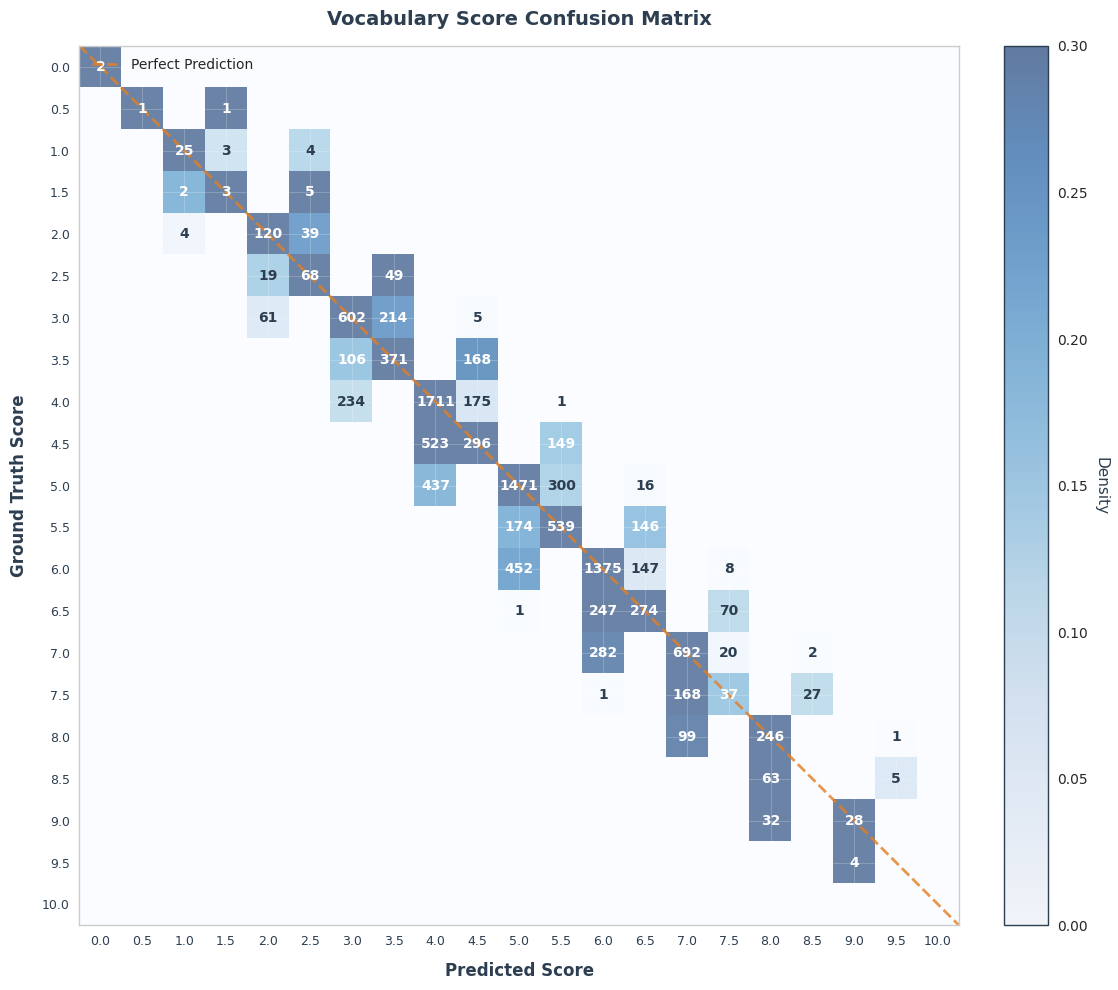

📊 Grammar Confusion Matrix


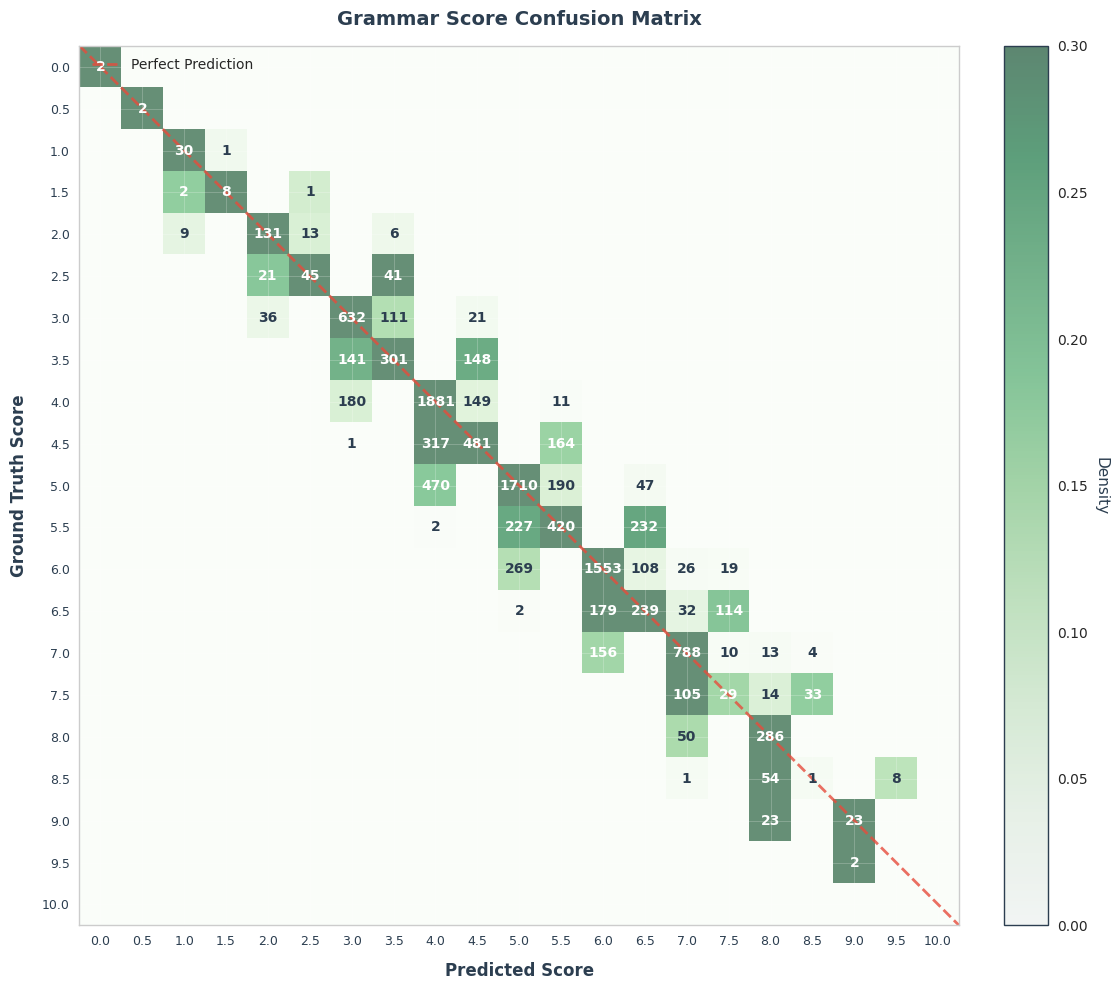

📊 Pronunciation Confusion Matrix


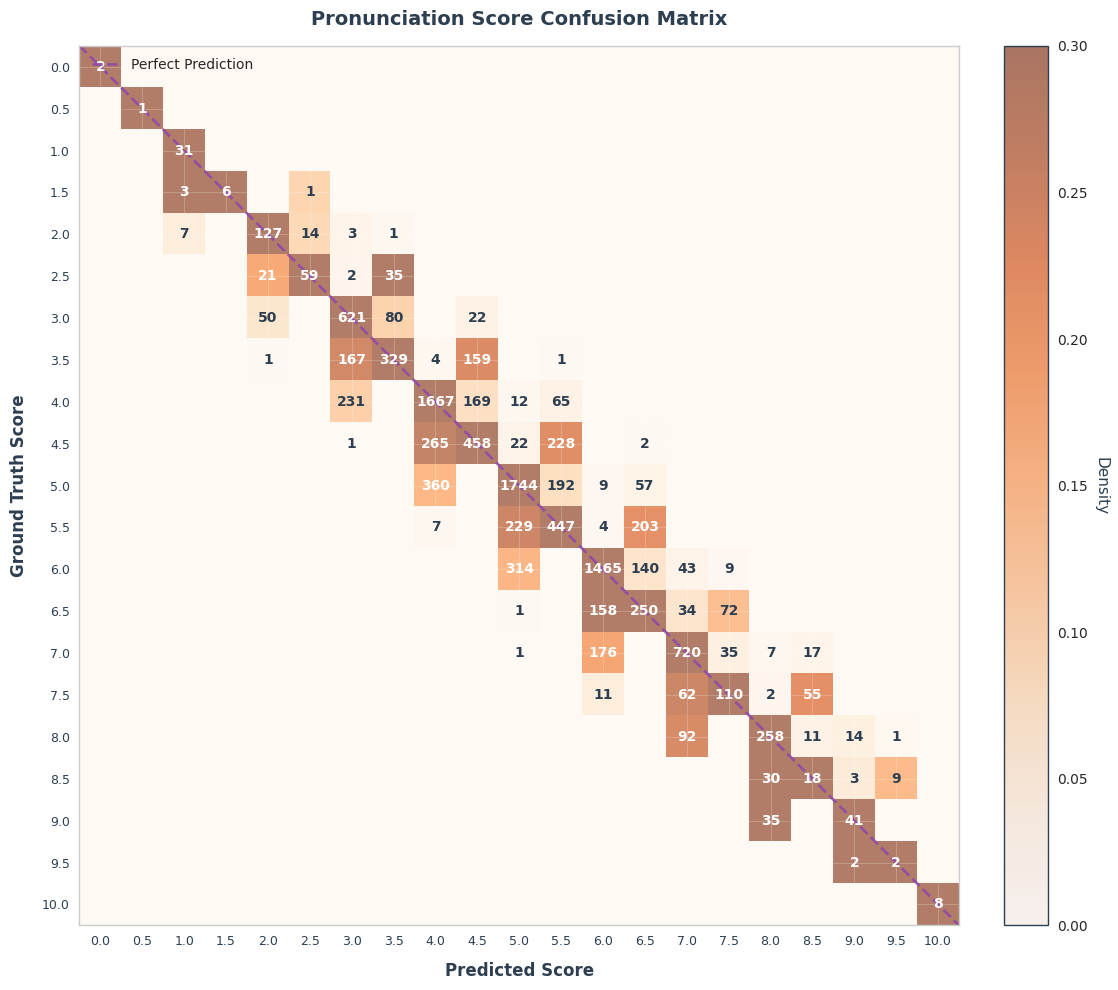

📊 Fluency Confusion Matrix


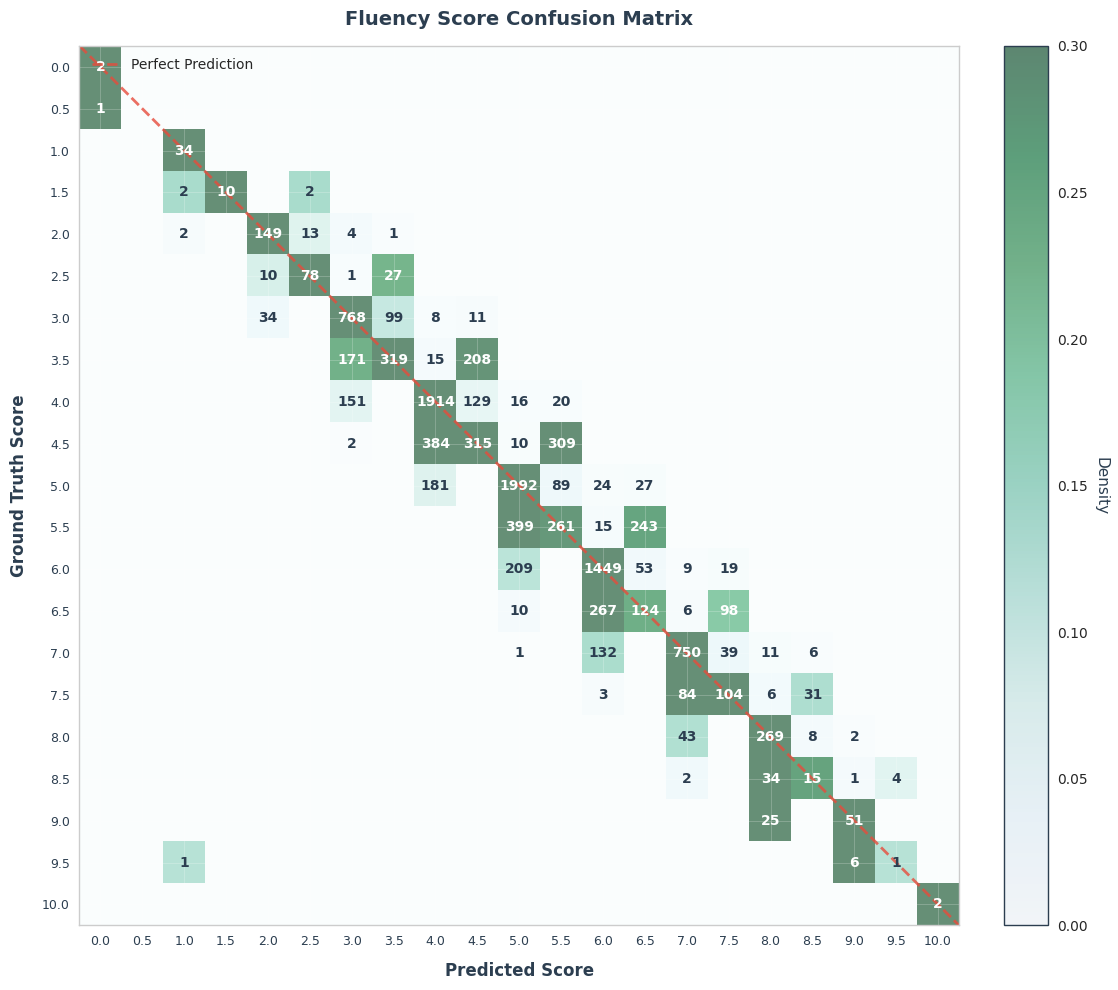

📊 Discourse Confusion Matrix


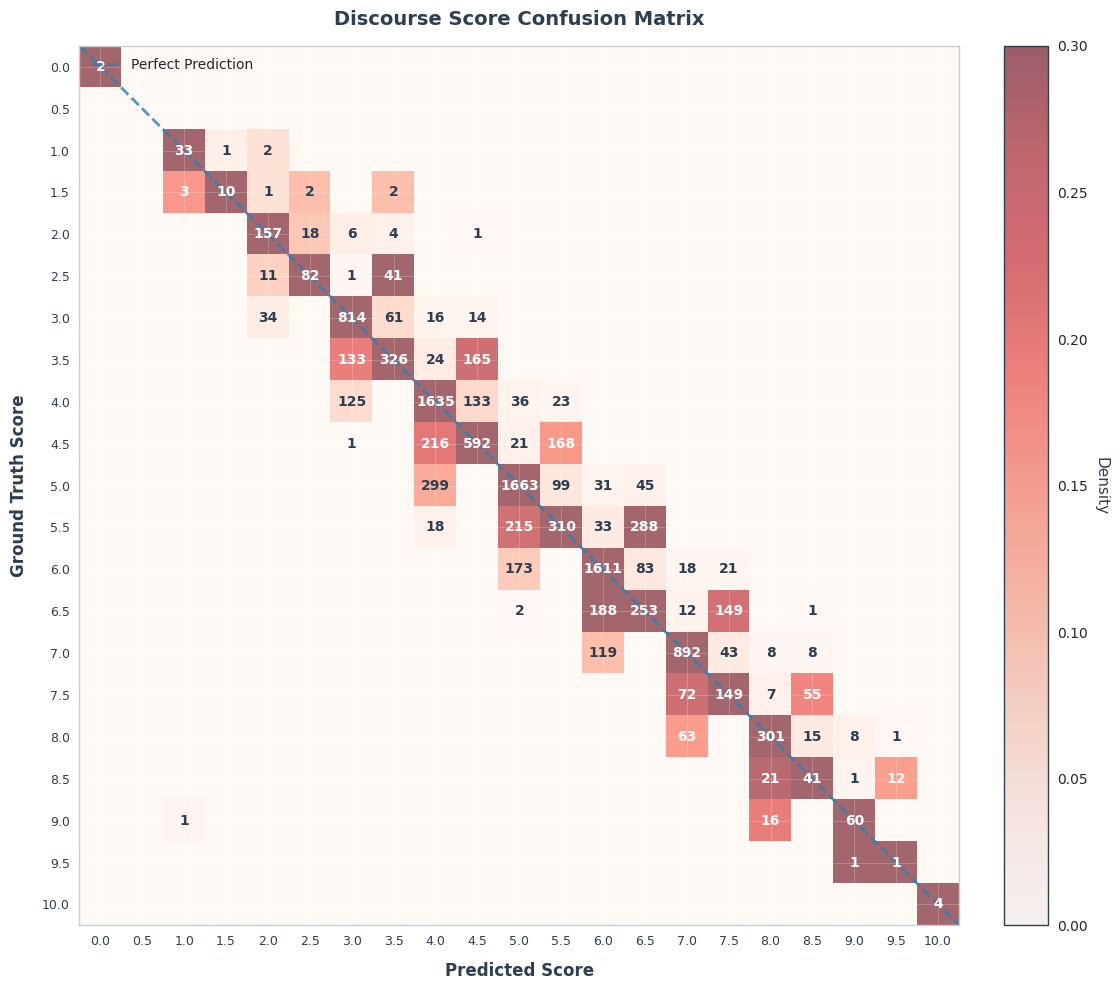

In [21]:
def plot_confusion_matrix(y_true, y_pred, title, figsize=(12, 10), color_style='soft'):
    """
    Clean, minimalist confusion matrix with only counts - no percentages.
    """
    # Round and convert
    y_true_rounded = np.round(y_true * 2) / 2
    y_pred_rounded = np.round(y_pred * 2) / 2
    y_true_str = [f"{x:.1f}" for x in y_true_rounded]
    y_pred_str = [f"{x:.1f}" for x in y_pred_rounded]
    
    scores = np.arange(0, 10.5, 0.5)
    scores_str = [f"{x:.1f}" for x in scores]
    
    cm = confusion_matrix(y_true_str, y_pred_str, labels=scores_str)
    cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    cm_norm = np.nan_to_num(cm_norm)
    
    # Create clean figure
    fig = plt.figure(figsize=figsize, facecolor='white')
    ax = plt.subplot(111, facecolor='white')
    
    # Color schemes for 5 categories
    color_schemes = {
        'soft': (plt.cm.Purples, '#E74C3C'),
        'ocean': (plt.cm.Blues, '#E67E22'),
        'mint': (plt.cm.Greens, '#E74C3C'),
        'sunset': (plt.cm.Oranges, '#8E44AD'),
        'forest': (plt.cm.BuGn, '#E74C3C'),
        'rose': (plt.cm.Reds, '#2980B9')
    }
    
    cmap, diagonal_color = color_schemes.get(color_style, color_schemes['soft'])
    text_dark = '#2C3E50'
    
    # Plot with very light colors
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=cmap,
                   vmin=0, vmax=0.3, alpha=0.6)
    
    # Clean colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel('Density', rotation=-90, va="bottom", 
                       fontsize=11, color=text_dark)
    cbar.outline.set_linewidth(1)
    cbar.outline.set_edgecolor(text_dark)
    
    # Clean ticks
    tick_marks = np.arange(len(scores))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(scores, rotation=0, ha='center', fontsize=9, color=text_dark)
    ax.set_yticklabels(scores, fontsize=9, color=text_dark)
    
    # Add only count numbers - clean and simple
    for i in range(len(scores)):
        for j in range(len(scores)):
            if cm[i, j] > 0:
                count_text = f'{cm[i, j]}'
                
                # Choose text color based on background
                if cm_norm[i, j] > 0.15:
                    text_color = 'white'
                else:
                    text_color = text_dark
                
                ax.text(j, i, count_text, ha="center", va="center",
                       color=text_color, fontsize=10, fontweight='bold')
    
    # Simple diagonal line
    ax.plot([-.5, len(scores)-.5], [-.5, len(scores)-.5], 
            color=diagonal_color, linewidth=2, alpha=0.8, 
            linestyle='--', label='Perfect Prediction')
    
    # Clean labels
    ax.set_ylabel('Ground Truth Score', fontsize=12, fontweight='bold', 
                  labelpad=10, color=text_dark)
    ax.set_xlabel('Predicted Score', fontsize=12, fontweight='bold', 
                  labelpad=10, color=text_dark)
    ax.set_title(f'{title}', fontsize=14, fontweight='bold', 
                pad=15, color=text_dark)
    
    # Simple legend
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
    
    # Clean spines
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
        spine.set_linewidth(1)
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    return fig

# Plot All Confusion Matrices for 5 Categories
print("🎨 Available color styles:")
print("1. 'soft' - Light Purple")
print("2. 'ocean' - Light Blue") 
print("3. 'mint' - Light Green")
print("4. 'sunset' - Light Orange")
print("5. 'forest' - Light Teal")
print("6. 'rose' - Light Red")
print()

# Total Score Confusion Matrix
print("📊 Total Score Confusion Matrix")
fig1 = plot_confusion_matrix(
    df_clean['GT Total'].values,
    df_clean['Pred Total'].values,
    'Total Score Confusion Matrix',
    color_style='soft'
)
plt.show()

# Vocabulary Confusion Matrix
print("📊 Vocabulary Confusion Matrix")
fig2 = plot_confusion_matrix(
    df_clean['GT Vocabulary'].values,
    df_clean['Pred Vocabulary'].values,
    'Vocabulary Score Confusion Matrix',
    color_style='ocean'
)
plt.show()

# Grammar Confusion Matrix
print("📊 Grammar Confusion Matrix")
fig3 = plot_confusion_matrix(
    df_clean['GT Grammar'].values,
    df_clean['Pred Grammar'].values,
    'Grammar Score Confusion Matrix',
    color_style='mint'
)
plt.show()

# Pronunciation Confusion Matrix
print("📊 Pronunciation Confusion Matrix")
fig4 = plot_confusion_matrix(
    df_clean['GT Pronunciation'].values,
    df_clean['Pred Pronunciation'].values,
    'Pronunciation Score Confusion Matrix',
    color_style='sunset'
)
plt.show()

# Fluency Confusion Matrix
print("📊 Fluency Confusion Matrix")
fig5 = plot_confusion_matrix(
    df_clean['GT Fluency'].values,
    df_clean['Pred Fluency'].values,
    'Fluency Score Confusion Matrix',
    color_style='forest'
)
plt.show()

# Discourse Confusion Matrix
print("📊 Discourse Confusion Matrix")
fig6 = plot_confusion_matrix(
    df_clean['GT Discourse'].values,
    df_clean['Pred Discourse'].values,
    'Discourse Score Confusion Matrix',
    color_style='rose'
)
plt.show()

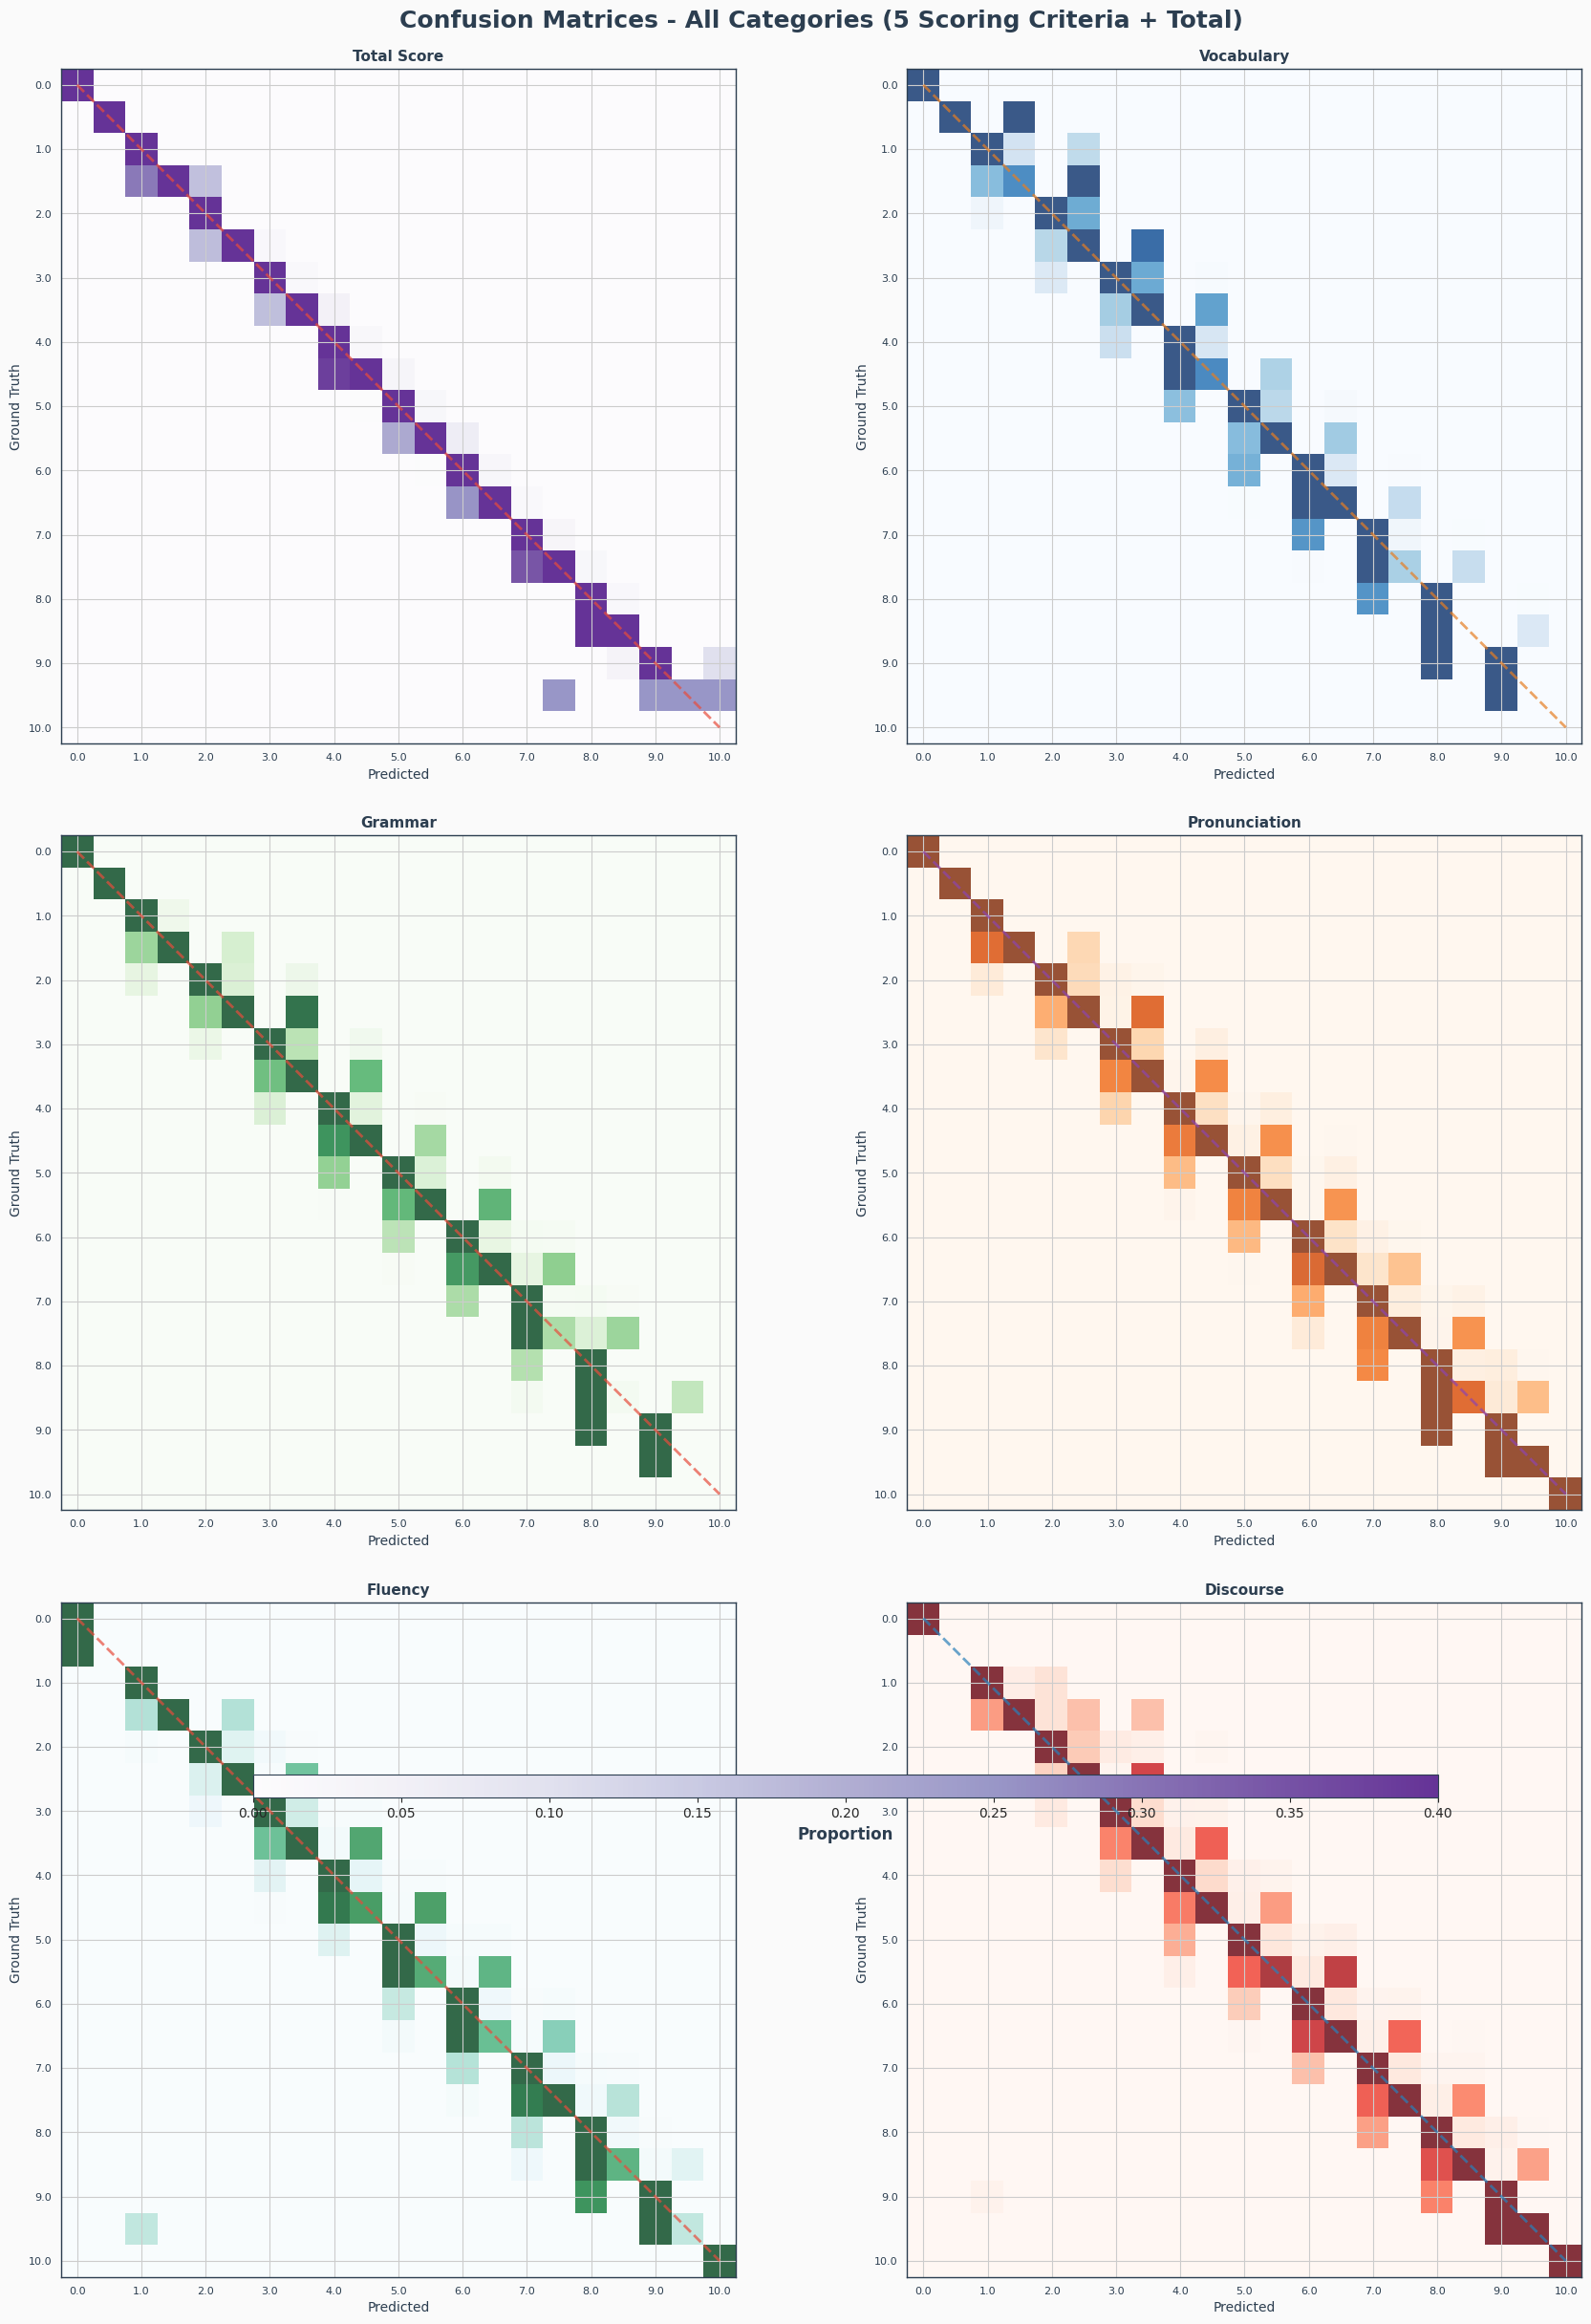

In [8]:
def plot_compact_confusion_matrix(y_true, y_pred, ax, title, color_style='soft'):
    """Plot compact confusion matrix on given axis with improved colors."""
    # Round to nearest 0.5
    y_true_rounded = np.round(y_true * 2) / 2
    y_pred_rounded = np.round(y_pred * 2) / 2
    
    # Convert to strings for categorical treatment
    y_true_str = [f"{x:.1f}" for x in y_true_rounded]
    y_pred_str = [f"{x:.1f}" for x in y_pred_rounded]
    
    # Get all possible scores
    possible_scores = np.arange(0, 10.5, 0.5)
    possible_scores_str = [f"{x:.1f}" for x in possible_scores]
    
    # Create confusion matrix
    cm = confusion_matrix(y_true_str, y_pred_str, labels=possible_scores_str)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized)
    
    # Color schemes for 5 categories
    color_schemes = {
        'soft': (plt.cm.Purples, '#E74C3C'),
        'ocean': (plt.cm.Blues, '#E67E22'),
        'mint': (plt.cm.Greens, '#E74C3C'),
        'sunset': (plt.cm.Oranges, '#8E44AD'),
        'forest': (plt.cm.BuGn, '#E74C3C'),
        'rose': (plt.cm.Reds, '#2980B9')
    }
    
    cmap, diagonal_color = color_schemes.get(color_style, color_schemes['soft'])
    
    # Plot with reduced intensity
    im = ax.imshow(cm_normalized, interpolation='nearest', cmap=cmap, 
                   vmin=0, vmax=0.4, alpha=0.8)
    
    # Set ticks (show every other tick to avoid crowding)
    tick_marks = np.arange(len(possible_scores))
    ax.set_xticks(tick_marks[::2])
    ax.set_yticks(tick_marks[::2])
    ax.set_xticklabels(possible_scores[::2], fontsize=8, color='#2C3E50')
    ax.set_yticklabels(possible_scores[::2], fontsize=8, color='#2C3E50')
    
    ax.set_ylabel('Ground Truth', fontsize=10, color='#2C3E50')
    ax.set_xlabel('Predicted', fontsize=10, color='#2C3E50')
    ax.set_title(title, fontsize=11, fontweight='bold', color='#2C3E50')
    
    # Add diagonal line with softer color
    ax.plot([0, len(possible_scores)-1], [0, len(possible_scores)-1], 
            color=diagonal_color, linewidth=2, alpha=0.7, linestyle='--')
    
    # Style spines
    for spine in ax.spines.values():
        spine.set_edgecolor('#2C3E50')
        spine.set_linewidth(1)
    
    return im

# Create 3x2 subplot for all 6 categories (including Total)
fig, axes = plt.subplots(3, 2, figsize=(20, 24), facecolor='#FAFAFA')
fig.patch.set_facecolor('#FAFAFA')

# Plot each category with different color styles
im1 = plot_compact_confusion_matrix(df_clean['GT Total'].values, 
                                     df_clean['Pred Total'].values,
                                     axes[0, 0], 'Total Score', 'soft')

im2 = plot_compact_confusion_matrix(df_clean['GT Vocabulary'].values,
                                     df_clean['Pred Vocabulary'].values,
                                     axes[0, 1], 'Vocabulary', 'ocean')

im3 = plot_compact_confusion_matrix(df_clean['GT Grammar'].values,
                                     df_clean['Pred Grammar'].values,
                                     axes[1, 0], 'Grammar', 'mint')

im4 = plot_compact_confusion_matrix(df_clean['GT Pronunciation'].values,
                                     df_clean['Pred Pronunciation'].values,
                                     axes[1, 1], 'Pronunciation', 'sunset')

im5 = plot_compact_confusion_matrix(df_clean['GT Fluency'].values,
                                     df_clean['Pred Fluency'].values,
                                     axes[2, 0], 'Fluency', 'forest')

im6 = plot_compact_confusion_matrix(df_clean['GT Discourse'].values,
                                     df_clean['Pred Discourse'].values,
                                     axes[2, 1], 'Discourse', 'rose')

# Add colorbar with better styling
cbar = fig.colorbar(im1, ax=axes, orientation='horizontal', 
                    pad=0.05, aspect=50, shrink=0.8)
cbar.set_label('Proportion', fontsize=12, color='#2C3E50', fontweight='bold')
cbar.outline.set_edgecolor('#2C3E50')

plt.suptitle('Confusion Matrices - All Categories (5 Scoring Criteria + Total)', 
             fontsize=18, fontweight='bold', y=0.995, color='#2C3E50')
plt.tight_layout()
plt.show()

In [9]:
def detailed_error_analysis(gt_col, pred_col, category_name):
    """Create detailed error analysis for a category."""
    errors = abs(df_clean[pred_col] - df_clean[gt_col])
    
    stats = {
        'Category': category_name,
        'MAE': f"{errors.mean():.4f}",
        'Median Error': f"{errors.median():.4f}",
        'Std Error': f"{errors.std():.4f}",
        'Max Error': f"{errors.max():.4f}",
        'Exact (0)': f"{(errors == 0).sum()} ({(errors == 0).sum()/len(errors)*100:.1f}%)",
        'Within 0.5': f"{(errors <= 0.5).sum()} ({(errors <= 0.5).sum()/len(errors)*100:.1f}%)",
        'Within 1.0': f"{(errors <= 1.0).sum()} ({(errors <= 1.0).sum()/len(errors)*100:.1f}%)",
        'Above 1.0': f"{(errors > 1.0).sum()} ({(errors > 1.0).sum()/len(errors)*100:.1f}%)"
    }
    return stats

# Create detailed analysis for all 5 categories + total
analysis_data = []
analysis_data.append(detailed_error_analysis('GT Total', 'Pred Total', 'Total'))
analysis_data.append(detailed_error_analysis('GT Vocabulary', 'Pred Vocabulary', 'Vocabulary'))
analysis_data.append(detailed_error_analysis('GT Grammar', 'Pred Grammar', 'Grammar'))
analysis_data.append(detailed_error_analysis('GT Pronunciation', 'Pred Pronunciation', 'Pronunciation'))
analysis_data.append(detailed_error_analysis('GT Fluency', 'Pred Fluency', 'Fluency'))
analysis_data.append(detailed_error_analysis('GT Discourse', 'Pred Discourse', 'Discourse'))

analysis_df = pd.DataFrame(analysis_data)

print("="*140)
print("DETAILED ERROR ANALYSIS - ALL 5 CATEGORIES + TOTAL")
print("="*140)
print(analysis_df.to_string(index=False))
print("="*140)

# Additional summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"Overall MAE across all categories:")
categories = ['total_error', 'vocabulary_error', 'grammar_error', 'pronunciation_error', 'fluency_error', 'discourse_error']
category_names = ['Total', 'Vocabulary', 'Grammar', 'Pronunciation', 'Fluency', 'Discourse']

for cat, name in zip(categories, category_names):
    print(f"{name:13}: {df_clean[cat].mean():.4f}")

print(f"\nAverage MAE (excluding Total): {df_clean[categories[1:]].mean().mean():.4f}")
print("="*80)

DETAILED ERROR ANALYSIS - ALL 5 CATEGORIES + TOTAL
     Category    MAE Median Error Std Error Max Error     Exact (0)     Within 0.5     Within 1.0  Above 1.0
        Total 0.0748       0.0000    0.1800    2.0000 10491 (85.1%) 12320 (100.0%) 12323 (100.0%)   2 (0.0%)
   Vocabulary 0.2744       0.0000    0.3959    1.5000  7861 (63.8%)  10065 (81.7%)  12286 (99.7%)  39 (0.3%)
      Grammar 0.2419       0.0000    0.3954    1.5000  8562 (69.5%)  10238 (83.1%)  12211 (99.1%) 114 (0.9%)
Pronunciation 0.2626       0.0000    0.4155    2.0000  8364 (67.9%)  10013 (81.2%)  12128 (98.4%) 197 (1.6%)
      Fluency 0.2317       0.0000    0.3901    8.5000  8607 (69.8%)  10449 (84.8%)  12222 (99.2%) 103 (0.8%)
    Discourse 0.2241       0.0000    0.3987    8.0000  8936 (72.5%)  10349 (84.0%)  12183 (98.8%) 142 (1.2%)

SUMMARY STATISTICS
Overall MAE across all categories:
Total        : 0.0748
Vocabulary   : 0.2744
Grammar      : 0.2419
Pronunciation: 0.2626
Fluency      : 0.2317
Discourse    : 0.2241

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# File paths from convert_data.py
files = {
    "train": "/home/user06/data/Speaking_VSTEP/Label/after_filter/balanced_vstep_dataset_v2.csv",
    "val": "/home/user06/data/Speaking_VSTEP/Label/after_filter/val_new_clean.csv", 
    "test": "/home/user06/data/Speaking_VSTEP/Label/after_filter/test_new_clean.csv"
}

# Load datasets
datasets = {}
for split, filepath in files.items():
    if os.path.exists(filepath):
        datasets[split] = pd.read_csv(filepath)
        print(f"✅ Loaded {split}: {len(datasets[split])} samples")
        print(f"   Columns: {list(datasets[split].columns)}")
    else:
        print(f"❌ File not found: {filepath}")
    print()

# Basic statistics
print("="*60)
print("BASIC DATASET STATISTICS")
print("="*60)
for split, df in datasets.items():
    print(f"{split.upper():>5}: {len(df):>6} samples")

total_samples = sum(len(df) for df in datasets.values())
print(f"{'TOTAL':>5}: {total_samples:>6} samples")
print("="*60)

✅ Loaded train: 10119 samples
   Columns: ['Candidate_ID', 'absolute_path', 'vocabulary', 'grammar', 'pronunciation', 'fluency', 'content', 'final', 'text', 'subfolder', 'audio_path', 'exists', 'question_type', 'processed_audio_path', 'is_part3']

✅ Loaded val: 5438 samples
   Columns: ['Candidate_ID', 'absolute_path', 'vocabulary', 'grammar', 'pronunciation', 'fluency', 'content', 'final', 'text', 'subfolder', 'audio_path', 'exists', 'question_type']

✅ Loaded test: 12325 samples
   Columns: ['Candidate_ID', 'absolute_path', 'vocabulary', 'grammar', 'pronunciation', 'fluency', 'content', 'final', 'text', 'subfolder', 'audio_path', 'exists', 'question_type']

BASIC DATASET STATISTICS
TRAIN:  10119 samples
  VAL:   5438 samples
 TEST:  12325 samples
TOTAL:  27882 samples


In [3]:
def analyze_score_distribution(datasets):
    """Analyze score distributions across all splits"""
    
    # Score columns based on convert_data.py format
    score_columns = ['vocabulary', 'grammar', 'pronunciation', 'fluency', 'content', 'final']
    
    print("📊 SCORE DISTRIBUTION ANALYSIS")
    print("="*80)
    print(f"Score columns: {score_columns}")
    print()
    
    # For each score column, show distribution
    for col in score_columns:
        print(f"\n📈 Distribution for '{col}':")
        print("-" * 50)
        
        for split, df in datasets.items():
            if col in df.columns:
                # Convert to numeric if needed
                scores = pd.to_numeric(df[col], errors='coerce').dropna()
                
                if len(scores) > 0:
                    print(f"\n{split.upper()} ({len(scores)} samples):")
                    print(f"  Range: {scores.min():.1f} - {scores.max():.1f}")
                    print(f"  Mean:  {scores.mean():.2f} ± {scores.std():.2f}")
                    print(f"  Median: {scores.median():.1f}")
                    
                    # Score distribution (count for each score)
                    score_counts = scores.value_counts().sort_index()
                    print(f"  Distribution:")
                    for score, count in score_counts.items():
                        percentage = count/len(scores)*100
                        print(f"    {score:>4.1f}: {count:>4} ({percentage:>5.1f}%)")
                    
                    # if len(score_counts) > 15:
                    #     print(f"    ... and {len(score_counts)-15} more unique scores")

# Run analysis
analyze_score_distribution(datasets)

📊 SCORE DISTRIBUTION ANALYSIS
Score columns: ['vocabulary', 'grammar', 'pronunciation', 'fluency', 'content', 'final']


📈 Distribution for 'vocabulary':
--------------------------------------------------

TRAIN (10119 samples):
  Range: 0.0 - 10.0
  Mean:  5.63 ± 2.26
  Median: 6.0
  Distribution:
     0.0:   13 (  0.1%)
     0.5:    7 (  0.1%)
     1.0:  149 (  1.5%)
     1.5:   66 (  0.7%)
     2.0:  801 (  7.9%)
     2.5:  473 (  4.7%)
     3.0:  834 (  8.2%)
     3.5:  314 (  3.1%)
     4.0:  654 (  6.5%)
     4.5:  308 (  3.0%)
     5.0:  623 (  6.2%)
     5.5:  285 (  2.8%)
     6.0:  697 (  6.9%)
     6.5:  295 (  2.9%)
     7.0: 1275 ( 12.6%)
     7.5:  923 (  9.1%)
     8.0: 1740 ( 17.2%)
     8.5:  368 (  3.6%)
     9.0:  277 (  2.7%)
     9.5:   14 (  0.1%)
    10.0:    3 (  0.0%)

VAL (5438 samples):
  Range: 1.0 - 9.0
  Mean:  5.07 ± 1.41
  Median: 5.0
  Distribution:
     1.0:   17 (  0.3%)
     1.5:    6 (  0.1%)
     2.0:   74 (  1.4%)
     2.5:   65 (  1.2%)
     3.0:

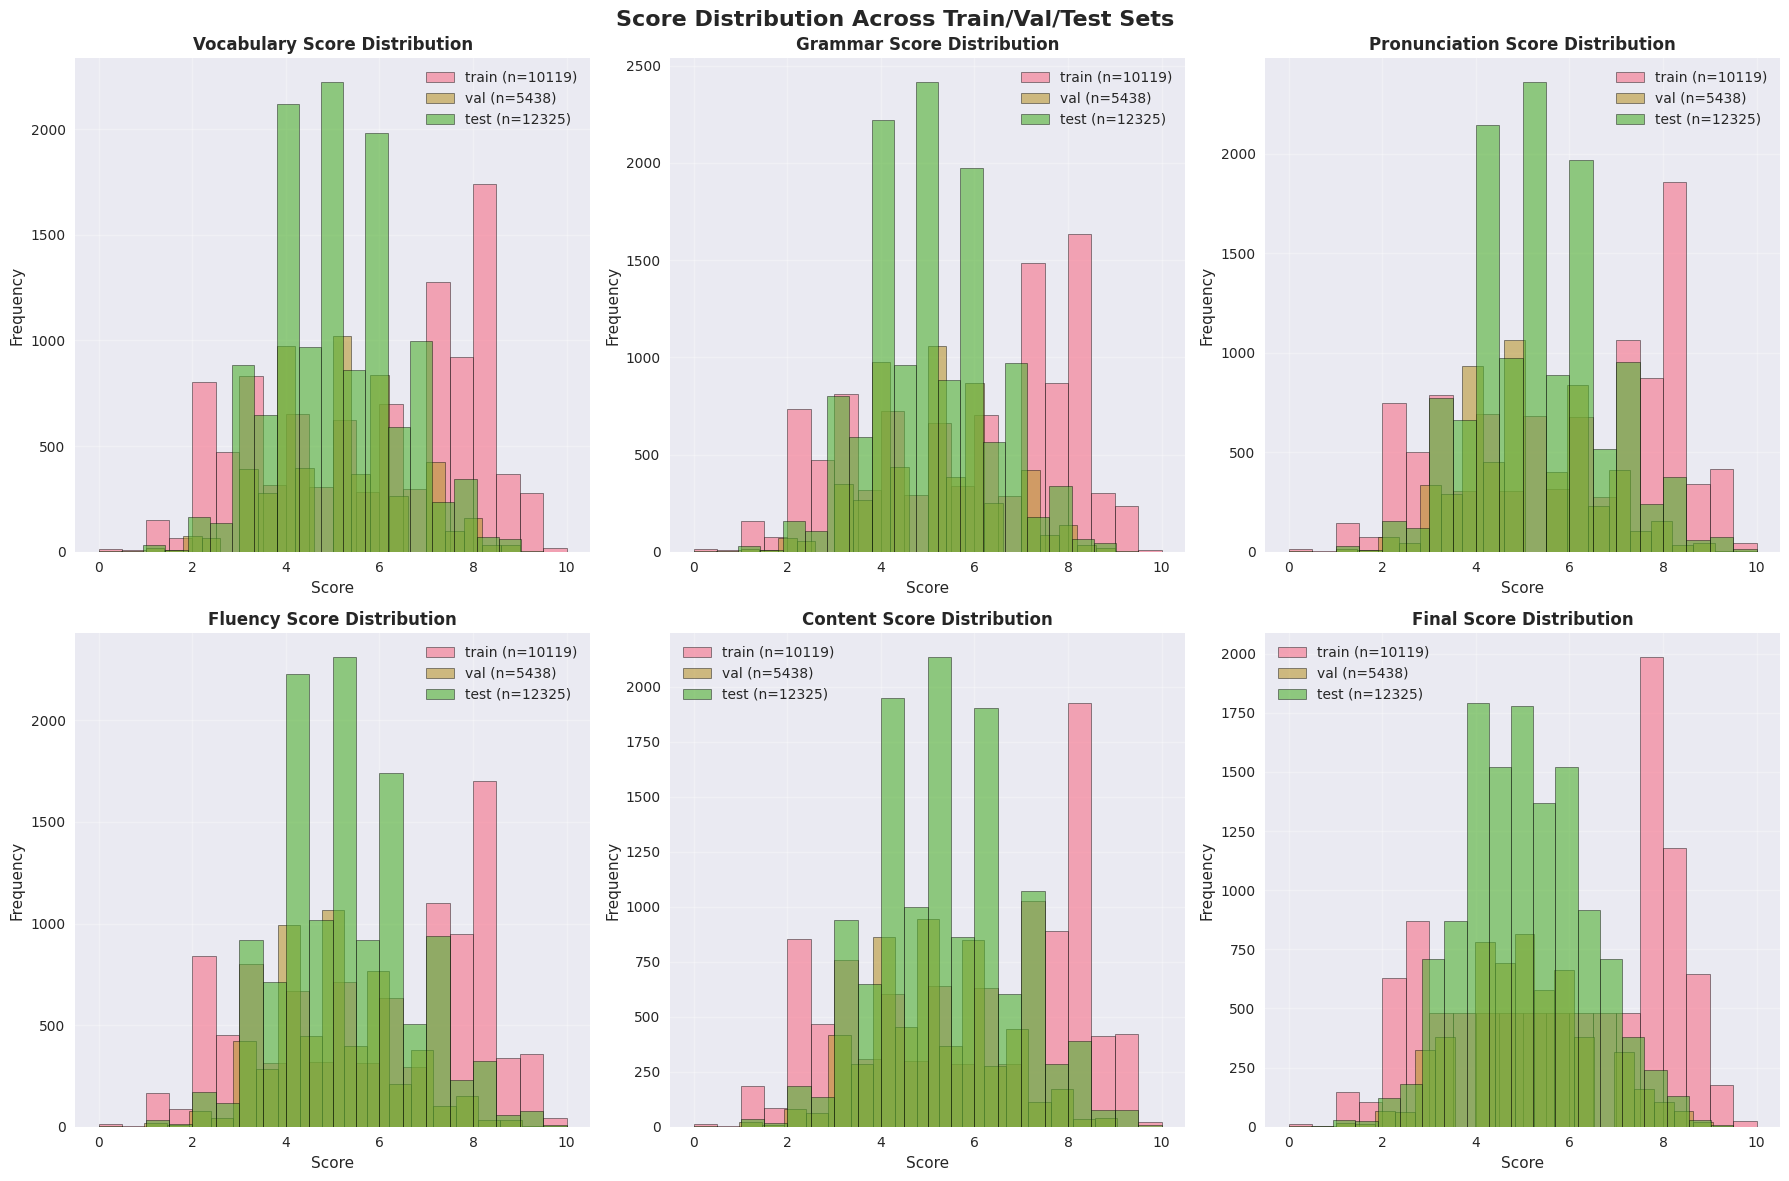

In [14]:
def create_score_distribution_plots(datasets):
    """Create visual plots for score distributions"""
    
    score_columns = ['vocabulary', 'grammar', 'pronunciation', 'fluency', 'content', 'final']
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Score Distribution Across Train/Val/Test Sets', fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    for idx, col in enumerate(score_columns):
        ax = axes[idx]
        
        # Plot histogram for each split
        for split, df in datasets.items():
            if col in df.columns:
                scores = pd.to_numeric(df[col], errors='coerce').dropna()
                ax.hist(scores, bins=20, alpha=0.6, label=f'{split} (n={len(scores)})', 
                       edgecolor='black', linewidth=0.5)
        
        ax.set_title(f'{col.title()} Score Distribution', fontweight='bold')
        ax.set_xlabel('Score')
        ax.set_ylabel('Frequency')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create plots
create_score_distribution_plots(datasets)

In [15]:
def analyze_audio_files(datasets):
    """Analyze audio files and find overlaps between splits"""
    
    print("🎵 AUDIO FILE ANALYSIS")
    print("="*80)
    
    # Audio-related columns from convert_data.py format
    audio_columns = ['absolute_path', 'audio_path', 'processed_audio_path']
    
    print(f"Audio-related columns: {audio_columns}")
    print()
    
    # Extract unique audio files from each split
    audio_files = {}
    for split, df in datasets.items():
        files_in_split = set()
        
        for col in audio_columns:
            if col in df.columns:
                # Extract filenames (remove paths, keep only filename)
                files = df[col].dropna().apply(lambda x: os.path.basename(str(x)) if pd.notna(x) else None)
                files = files.dropna().unique()
                files_in_split.update(files)
        
        audio_files[split] = files_in_split
        print(f"{split.upper()}: {len(files_in_split)} unique audio files")
    
    return audio_files

def find_overlaps(audio_files):
    """Find overlapping audio files between splits"""
    
    print("\n🔍 OVERLAP ANALYSIS")
    print("="*50)
    
    splits = list(audio_files.keys())
    
    # Pairwise overlaps
    for i, split1 in enumerate(splits):
        for split2 in splits[i+1:]:
            overlap = audio_files[split1].intersection(audio_files[split2])
            
            if overlap:
                print(f"\n❌ OVERLAP between {split1.upper()} and {split2.upper()}: {len(overlap)} files")
                if len(overlap) <= 10:
                    for file in sorted(overlap):
                        print(f"   - {file}")
                else:
                    for file in sorted(list(overlap)[:5]):
                        print(f"   - {file}")
                    print(f"   ... and {len(overlap)-5} more files")
            else:
                print(f"✅ No overlap between {split1.upper()} and {split2.upper()}")
    
    # Three-way overlap
    if len(splits) == 3:
        three_way = audio_files[splits[0]].intersection(audio_files[splits[1]]).intersection(audio_files[splits[2]])
        if three_way:
            print(f"\n❌ THREE-WAY OVERLAP: {len(three_way)} files in all splits")
            for file in sorted(three_way):
                print(f"   - {file}")
        else:
            print(f"\n✅ No files appear in all three splits")

# Run audio analysis
audio_files = analyze_audio_files(datasets)
find_overlaps(audio_files)

🎵 AUDIO FILE ANALYSIS
Audio-related columns: ['absolute_path', 'audio_path', 'processed_audio_path']

TRAIN: 19446 unique audio files
VAL: 6270 unique audio files
TEST: 13976 unique audio files

🔍 OVERLAP ANALYSIS
✅ No overlap between TRAIN and VAL
✅ No overlap between TRAIN and TEST
✅ No overlap between VAL and TEST

✅ No files appear in all three splits
